In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE

# **1. Load dataset**

In [20]:
diabetes_df = pd.read_csv("diabetes_data.csv")
diabetes_df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [21]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


# **2. Adjust 'gender' and 'smoking_history' column**

In [23]:
mapping = {
    'Other': 'Male',
    'Female': 'Female',
    'Male': 'Male'
}
diabetes_df['gender'] = diabetes_df['gender'].map(mapping)

In [24]:
mapping = {
    'never': 'never',
    'No Info': 'unknown', # "no info" -> "unknown"
    'current': 'current',
    'former': 'former',
    'not current': 'former', # "not current" -> "former"
    'ever': 'former' # "ever" -> "former"
}

diabetes_df['smoking_history'] = diabetes_df['smoking_history'].map(mapping)

# **3. Split Train/Val/Test first to prevents data leakage**

In [25]:
X = diabetes_df.drop(columns=['diabetes'])
y = diabetes_df['diabetes']

In [26]:
# first split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [27]:
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print()
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (70000, 8)
X_val shape: (15000, 8)
X_test shape: (15000, 8)

y_train shape: (70000,)
y_val shape: (15000,)
y_test shape: (15000,)


# **Feature Engineering on 'Training data' only**

# **4. Check for missing values and handle them**

In [28]:
print("X_train dataset:")
print(X_train.isnull().sum())

print("\nX_val dataset:")
print(X_val.isnull().sum())

print("\nX_test dataset:")
print(X_test.isnull().sum())

X_train dataset:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
dtype: int64

X_val dataset:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
dtype: int64

X_test dataset:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
dtype: int64


# **5. Fix Outliers**

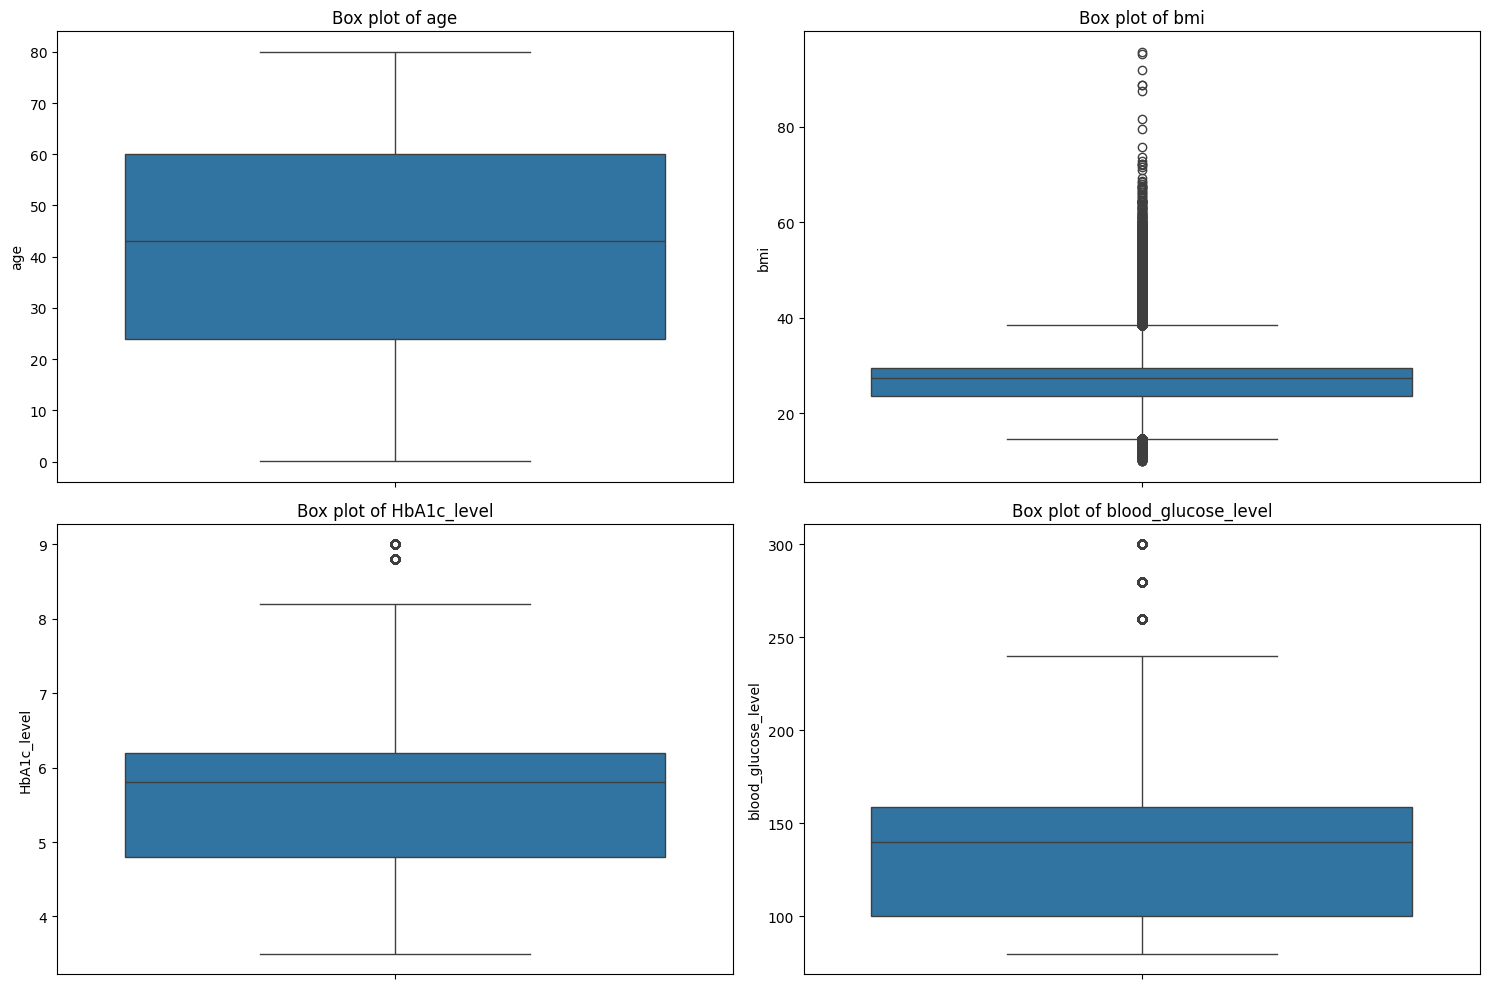

In [29]:
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
  plt.subplot(2, 2, i + 1)
  sns.boxplot(data=X_train, y=col)
  plt.title(f'Box plot of {col}')

plt.tight_layout()
plt.show()

In [30]:
# Handle outliers for only train dataset using IQR method
for col in ['bmi', 'HbA1c_level', 'blood_glucose_level']:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_train[col] = np.where(X_train[col] < lower_bound, lower_bound, X_train[col])
    X_train[col] = np.where(X_train[col] > upper_bound, upper_bound, X_train[col])

    # Apply the same bounds to validation and test sets
    X_val[col] = np.where(X_val[col] < lower_bound, lower_bound, X_val[col])
    X_val[col] = np.where(X_val[col] > upper_bound, upper_bound, X_val[col])

    X_test[col] = np.where(X_test[col] < lower_bound, lower_bound, X_test[col])
    X_test[col] = np.where(X_test[col] > upper_bound, upper_bound, X_test[col])

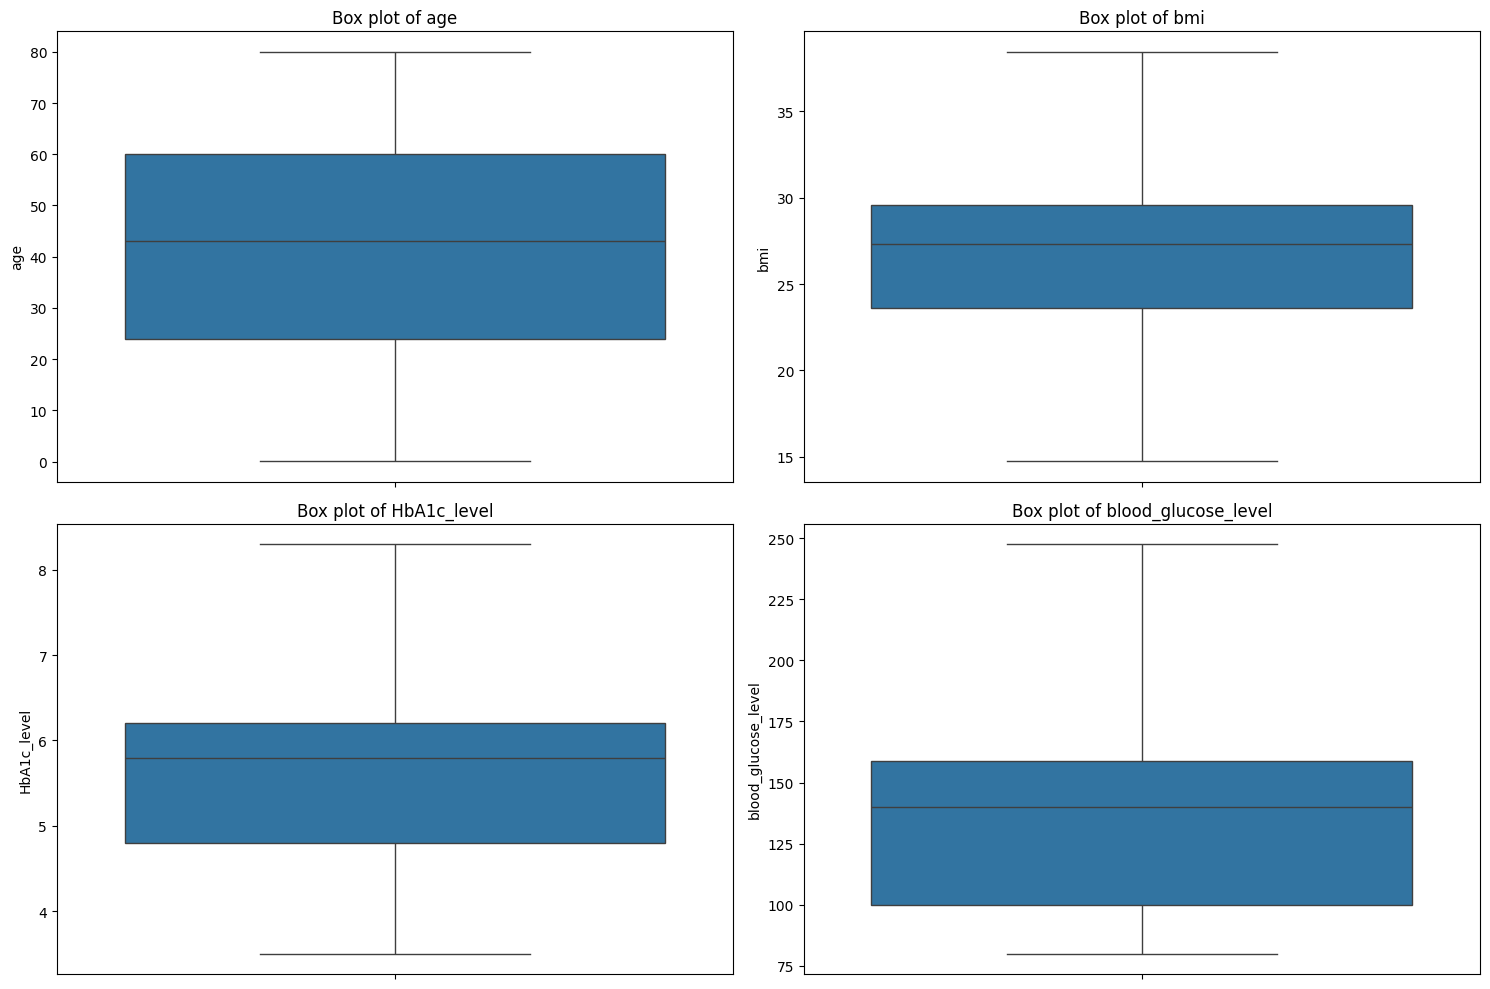

In [31]:
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
  plt.subplot(2, 2, i + 1)
  sns.boxplot(data=X_train, y=col)
  plt.title(f'Box plot of {col}')

plt.tight_layout()
plt.show()

# **6. Encode categorical features**

In [32]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder for 'gender'
# handle_unknown='ignore' will set unseen categories to all zeros, preventing errors.
# sparse_output=False ensures a dense array output, which is easier to convert to DataFrame.
# To drop 'Male', we order categories as ['Male', 'Female', 'Other'] and set drop='first'.
gender_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, categories=[['Male', 'Female']], drop='first')

# Fit on X_train 'gender' and transform all datasets
X_train_gender_encoded = gender_ohe.fit_transform(X_train[['gender']])
X_val_gender_encoded = gender_ohe.transform(X_val[['gender']])
X_test_gender_encoded = gender_ohe.transform(X_test[['gender']])

# Get feature names for the new columns
gender_cols = gender_ohe.get_feature_names_out(['gender'])

# Convert to DataFrame and concatenate with original DataFrames, dropping the old 'gender' column
X_train = pd.concat([X_train.drop(columns=['gender']), pd.DataFrame(X_train_gender_encoded, columns=gender_cols, index=X_train.index)], axis=1)
X_val = pd.concat([X_val.drop(columns=['gender']), pd.DataFrame(X_val_gender_encoded, columns=gender_cols, index=X_val.index)], axis=1)
X_test = pd.concat([X_test.drop(columns=['gender']), pd.DataFrame(X_test_gender_encoded, columns=gender_cols, index=X_test.index)], axis=1)

# Initialize OneHotEncoder for 'smoking_history'
smoking_history_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on X_train 'smoking_history' and transform all datasets
X_train_smoking_encoded = smoking_history_ohe.fit_transform(X_train[['smoking_history']])
X_val_smoking_encoded = smoking_history_ohe.transform(X_val[['smoking_history']])
X_test_smoking_encoded = smoking_history_ohe.transform(X_test[['smoking_history']])

# Get feature names for the new columns
smoking_history_cols = smoking_history_ohe.get_feature_names_out(['smoking_history'])

# Convert to DataFrame and concatenate with original DataFrames, dropping the old 'smoking_history' column
X_train = pd.concat([X_train.drop(columns=['smoking_history']), pd.DataFrame(X_train_smoking_encoded, columns=smoking_history_cols, index=X_train.index)], axis=1)
X_val = pd.concat([X_val.drop(columns=['smoking_history']), pd.DataFrame(X_val_smoking_encoded, columns=smoking_history_cols, index=X_val.index)], axis=1)
X_test = pd.concat([X_test.drop(columns=['smoking_history']), pd.DataFrame(X_test_smoking_encoded, columns=smoking_history_cols, index=X_test.index)], axis=1)

# **7. Scale numerical features**

In [33]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Apply to train data
X_train[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']] = scaler.fit_transform(
    X_train[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']]
)

# Apply same scaling to val and test data
X_val[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']] = scaler.transform(
    X_val[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']]
)

X_test[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']] = scaler.transform(
    X_test[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']]
)

# **8. Feature selection**

In [34]:
# Create a copy of training data for feature selection
# This way we can keep original X_train safe
X_train_for_selection = X_train.copy()
X_train_for_selection['diabetes'] = y_train.values

# Calculate correlations
correlation_with_diabetes = X_train_for_selection.corr(numeric_only=True)['diabetes'].drop('diabetes').sort_values(ascending=False)

print("Correlation of features with 'diabetes':")
print(correlation_with_diabetes)

Correlation of features with 'diabetes':
HbA1c_level                0.385438
blood_glucose_level        0.384867
age                        0.256300
bmi                        0.209709
hypertension               0.201312
heart_disease              0.169258
smoking_history_former     0.097269
smoking_history_never      0.027482
smoking_history_current    0.016745
gender_Female             -0.034801
smoking_history_unknown   -0.118463
Name: diabetes, dtype: float64


In [35]:
selected_features = correlation_with_diabetes[abs(correlation_with_diabetes) > 0.01].index.tolist()

# Ensure the selected features are in the original order of X_train
original_x_train_cols = X_train.columns.tolist()
selected_features_ordered = [col for col in original_x_train_cols if col in selected_features]

print(f"\nFeatures selected based on absolute correlation > 0.05 with 'diabetes':\n{selected_features_ordered}")

# Apply feature selection to training data
X_train_selected = X_train[selected_features_ordered]

# Apply same feature selection to valid and test data
X_val_selected = X_val[selected_features_ordered]
X_test_selected = X_test[selected_features_ordered]


Features selected based on absolute correlation > 0.05 with 'diabetes':
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Female', 'smoking_history_current', 'smoking_history_former', 'smoking_history_never', 'smoking_history_unknown']


# **9. Balancing the dataset (for classification only)**

In [36]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data with selected features
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train)

In [37]:
print(y_train.value_counts())
print()
print(y_train_balanced.value_counts())

diabetes
0    64050
1     5950
Name: count, dtype: int64

diabetes
0    64050
1    64050
Name: count, dtype: int64


# **10. Save the new (preprocessed) train and test datasets**

In [38]:
# Save balanced training data
pd.DataFrame(X_train_balanced, columns=selected_features).to_csv('X_train_balanced.csv', index=False)
y_train_balanced.to_csv('y_train_balanced.csv', index=False)

# Save val data
pd.DataFrame(X_val_selected, columns=selected_features).to_csv('X_val.csv', index=False)
y_val.to_csv('y_val.csv', index=False)

# Save test data (UNBALANCED - keep it as is for proper evaluation)
pd.DataFrame(X_test_selected, columns=selected_features).to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("All processed datasets saved")

All processed datasets saved


In [39]:
import joblib  # Better than pickle for large objects

# Save scaler right after fitting it
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved to scaler.pkl")

Scaler saved to scaler.pkl
